### Полиномиальные модели

#### Цель работы

На практике познакомиться с моделями полиномиальной регрессии и классификации, понять влияние степени полинома на вычислительную сложность и точность модели.

#### Содержание работы

1. Загрузите учебный набор данных для регрессии "gen_regression".
1. Постройте модель парной линейной регрессии, оцените ее эффективность, изобразите модель на графике.
1. Постройте модель полиномиальной регрессии второго порядка. Сравните ее эффективность с первой моделью.
1. Загрузите набор данных для классификации "gen_classification".
1. Постройте линейную классификацию, изобразите ее на графике и оцените точность.
1. Введите в данные признаки третьего порядка и постройте классификацию. Сравните с предыдущей моделью.
1. Загрузите набор данных, содержащий данные о продаже домов в округе King county, США.
1. Постройте на этом датасете линейную модель и полиномиальную второго порядка. Изобразите на графике и сравните эффективность.

#### Методические указания

Начнем как всегда с импорта необходимых библиотек:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##### Парная регрессия

Прочитаем первый датасет по ссылке:


In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv")


Выведем его первые строчки на экран, чтобы убедиться, что он был прочитан правильно и познакомиться с его структурой:

In [3]:
data.head()

,Unnamed: 0,x,y
0,0,96.597780,97761.592016
1,1,48.002892,27613.989207
2,2,47.939756,29410.187753
3,3,47.809026,15789.597531
4,4,69.784427,20953.383453


Это датасет для решения задачи парной регрессии. Мы видим один столбец, названный x и один столбец y. Оба они выражены в численном виде. Видим, что датасет прочитался неправильно. Однако сейчас нам проще не исправлять код чтения, а сразу выделить необходимые столбцы в переменные:

In [4]:
X = data.x
y = data.y

Так как датасет парный, мы можем изобразить зависимость между единственным атрибутом и целевой переменной на графике:

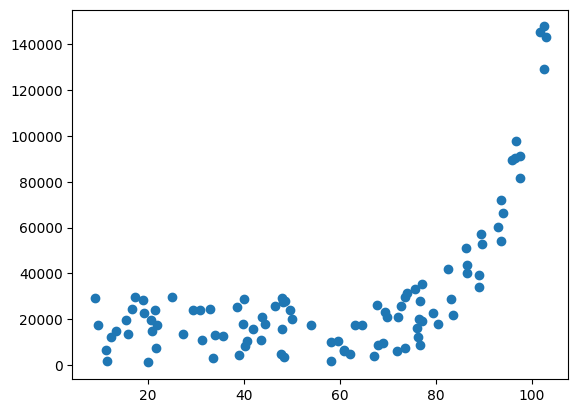

In [5]:
plt.scatter(X, y)

Здесь мы видим наличие нелинейной зависимости между атрибутом и целевой переменной. Мы пока не знаем, какова именно эта зависимость и какая функция его приближает лучше всего. Мы будем пробовать строить полиномы разных степеней и смотреть, насколько точной получатся такие модели. Для эксперимента построим модель линейной регрессии. Для этого импортируем соответствующий класс из библиотеки и обучим модель:

Обратите внимание, что все объекты sklearn предполагают, что аргумент X представлен именно матрицей, то есть объектом класса DataFrame. В данном случае у нас X это Series, поэтому придется его преобразовать:

In [6]:
X = pd.DataFrame(X)

In [7]:
from sklearn.linear_model import LinearRegression
linear = LinearRegression().fit(X, y)

Теперь мы можем сгенерировать данные и построить линию регрессии:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


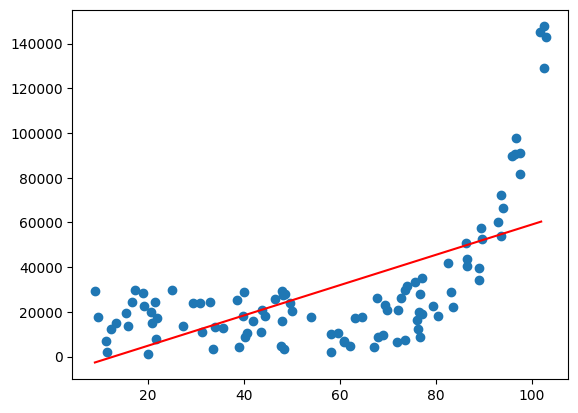

In [8]:
xx = np.arange(X.x.min(axis=0), X.x.max(axis=0))
yy = linear.predict(pd.DataFrame(xx))

plt.scatter(X.x, y)
plt.plot(xx, yy, c='r')

Как и ожидалось, линейная модель не очень хорошо аппроксимирует наши данные. Для более точной оценки эффективности моделей выведем значение коэффициента детерминации:

In [9]:
linear.score(X, y)

0.37467360318911636

Мы видим, что это значение (37%) довольно низко. Можно сделать обоснованный вывод о том, что данная модель имеет низкую точность.

Давайте попробуем построить полиномиальную регрессию второго порядка и посмотрим, улучшит ли это ситуацию. В библиотеке sklearn нет отдельного класса для полиномиальных моделей. Вместо этого, введение полиномиальных признаков происходит путем преобразования данных. Для этого служит специальный класс:

In [10]:
from sklearn.preprocessing import PolynomialFeatures

Для преобразования данных в sklearn создается отдельный объект. Чуть позже мы узнаем, зачем это нужно. Но поначалу работа с трансформацией данных может показаться немного неуклюжей. Но по другому действительно нельзя. Для начала надо создать объект трансформации - добавления полиномиальный признаков. При создании мы указываем степень полинома:

In [11]:
transformation = PolynomialFeatures(degree=2)

Теперь надо "обучить" объект трансформации на нашем датасете. Все объекты sklearn специально сделаны очень похоже по интерфейсу на модели машинного обучения. Это очень полезно при их комбинировании в конвейеры. Об этом поговорим позже. Сейчас нужно "подстроить" объект трансформации под наши данные:

In [12]:
transformation.fit(X)

PolynomialFeatures()

Теперь мы можем собственно преобразовать датасет:

In [13]:
X_2 = transformation.transform(X)

Мы всегда рекомендуем в таких случаях создавать именно новую переменную, а не перезаписывать имеющуюся. Это избавит нас от многих проблем при отладке и повторном выполнении кода. Давайте посмотрим на датасет, который получился в итоге:

In [14]:
X_2.shape
X_2[:5]

array([[1.00000000e+00, 9.65977805e+01, 9.33113119e+03],
       [1.00000000e+00, 4.80028921e+01, 2.30427765e+03],
       [1.00000000e+00, 4.79397558e+01, 2.29822018e+03],
       [1.00000000e+00, 4.78090258e+01, 2.28570295e+03],
       [1.00000000e+00, 6.97844271e+01, 4.86986627e+03]])

Мы видим, что он состоит из трех колонок. Первая - это автоматически добавляемая колонка, состоящая из одних единиц (так называемый bias). Ее добавление можно отключить. Вторая - это наш исходный _x_. А третья - это как раз $x^2$ - то есть полиномиальный признак.

Теперь мы можем обучить вторую модель на новой матрице признаков и уже знакомом векторе значений целевой переменной:



In [15]:
poly_2d = LinearRegression().fit(X_2, y)

Мы построили полиномиальную модель и хотим изобразить ее на графике. Для этого мы можем использовать уже имеющийся у нас массив xx. Но его теперь нужно преобразовать. Причем преобразовать именно так, как мы преобразовывали сам датасет. Именно для этого и служит объект трансформации. Единожды обучив его мы можем трансформировать единообразно сколько угодно разных датасетов. Применим еще раз нашу трансформацию:

In [16]:
xx_2d = transformation.transform(pd.DataFrame(xx))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


Вот теперь можно строить график:

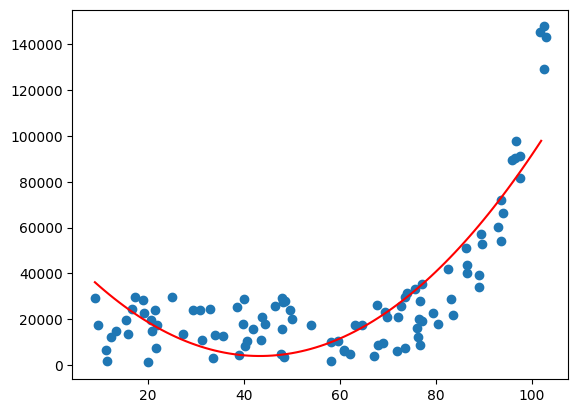

In [17]:
yy_2d = poly_2d.predict(xx_2d)
plt.scatter(X.x, y)
plt.plot(xx, yy_2d, c='r')

На графике мы видим, что линия регрессии уже стала кривой - это и есть наша кривая второго порядка. Она, как видно, гораздо ближе к точкам, чем линейна функция. Это численно подтверждает и значение коэффициента детерминации второй модели:

In [18]:
poly_2d.score(X_2, y)

0.7359753787024842

Таким образом можно сделать вывод, что вторая модель (полиномиальная регрессия второго порядка) значительно лучше первой (линейной) описывает точки нашего набора данных. А значи эта модель будет давать гораздо более точные предсказания.

##### Классификация

В качестве второго примера разберем применение полиномиальных моделей для задач классификации. Вы увидите, что на практике это не сильно отличается от их применения в задачах регрессии. Для начала как всегда загрузим датасет:


In [19]:
data = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/gen_classification.csv",
                   index_col=0)

In [20]:
data.head()

,x1,x2,y
0,0.048289,0.267592,1
1,1.363151,0.171123,0
2,-0.424253,0.893937,0
3,0.112344,0.565672,0
4,-1.262453,0.521735,0


После визуального осмотра загруженных данных выделим матрицу атрибутов и вектор целевой переменной:

In [21]:
y = data.y
X = data.drop(["y"], axis=1)

Построим этот датасет на графике. При предварительном анализе данных мы должны были увидеть, что в целевой переменной содержится всего два значения. Это значит, что перед нами задача бинарной классификации:

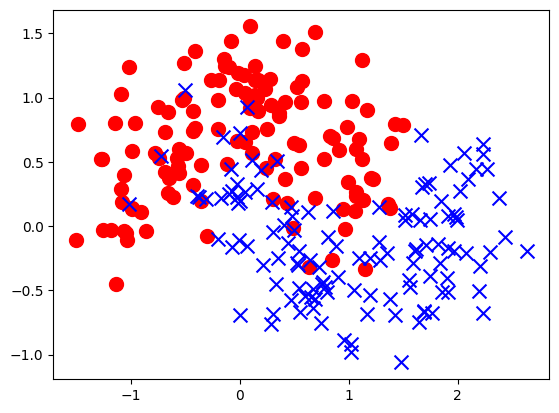

In [22]:
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

На графике ясно видно, что мы имеем дело с линейно неразделимым датасетом. Это может быть прямым показанием к использованию полиномиальной модели:

Но для начала, как всегда построим самую простую - линейную - модель. Так как мы имеем дело с классификацией, нам понадобится модель логистической регрессии. Для этого импортируем соответствующий класс:

In [23]:
from sklearn.linear_model import LogisticRegression

Создаем и сразу обучаем модель:

In [24]:
logistic = LogisticRegression().fit(X, y)

Пробуем изобразить модель на графике.

/tmp/ipykernel_21046/739733186.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.arange(X.min()[0], X.max()[0]+0.1, 0.01),
/tmp/ipykernel_21046/739733186.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  np.arange(X.min()[1], X.max()[1]+0.1, 0.01))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


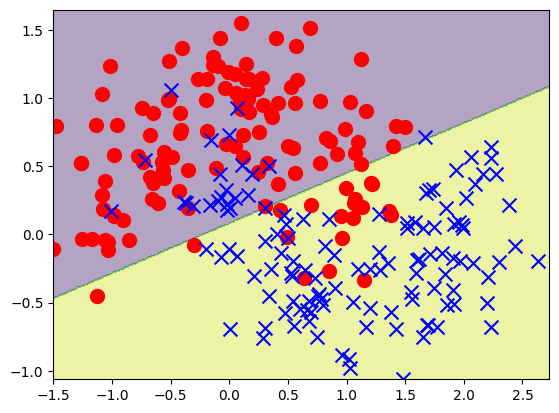

In [25]:
xx, yy = np.meshgrid(
    np.arange(X.min()[0], X.max()[0]+0.1, 0.01),
    np.arange(X.min()[1], X.max()[1]+0.1, 0.01))
XX = np.array(list(zip(xx.ravel(), yy.ravel()))).reshape((-1, 2))

Z = logistic.predict(XX).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

Мы увидим линейную границу принятия решений:

Очевидно, такая модель часто ошибается и не очень точна. Чтобы подтвердить такой вывод мы выведем значение метрики точности для нашей модели:

In [26]:
logistic.score(X, y)

0.832

Точность в 83% может показаться удовлетворительно, но из графика видно, насколько часто модель относит точки к неправильному классу. При анализе графика также можно предположить, что нелинейная (полиномиальная) граница принятия решения может нам существенно помочь.

Для построения нелинейной модели также создадим объект преобразования и применим его на нашей обучающей выборке (матрице атрибутов). Но сейчас мы сделаем все тоже самое короче. Для этого можно воспользоваться методом fit_transform(), который подстраивает преобразование и сразу применяет его:

In [27]:
class_transform = PolynomialFeatures(degree=3, include_bias=False)
X_3 = class_transform.fit_transform(X)

Здесь мы применяем полиномиальные признаки третьей степени. Обратите внимание, что мы не включаем столбец из единиц - bias. Он нам не нужен, так как модель логистической регрессии сама внутри себя использует свободный коэффициент, так называемый intercept. Выведем форму получившегося массива:

In [28]:
X_3.shape

(250, 9)

Исходных признаков два (`x1` и `x2`). При построении полинома **третьей степени** без добавления столбца единиц (`include_bias=False`) генерируются все возможные комбинации признаков с суммарной степенью от 1 до 3. Количество таких комбинаций равно числу сочетаний с повторениями:  
`C(2+3, 3) − 1 = C(5,3) − 1 = 10 − 1 = 9`.  
Вот эти 9 признаков:  
`x1, x2, x1², x1·x2, x2², x1³, x1²·x2, x1·x2², x2³`.

Теперь мы можем создать объект логистической регрессии и сразу же обучить его на данных:

In [29]:
class_3 = LogisticRegression().fit(X_3, y)

Изобразим получившуюся модель на графике. Обратите внимание, как мы используем объект преобразования и как мы повторно используем уже созданные служебные переменные:

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


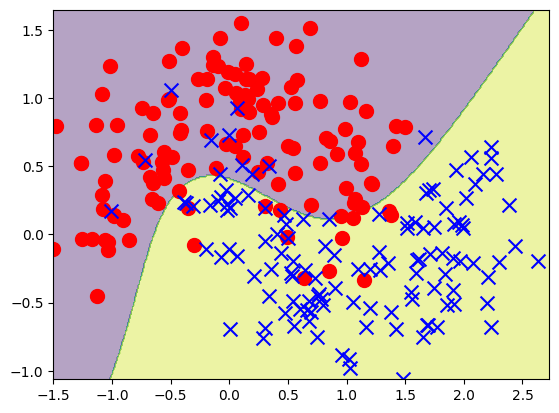

In [30]:
Z = class_3.predict(class_transform.transform(XX)).reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.4)
plt.scatter(X.iloc[:, 0][y==0], X.iloc[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X.iloc[:, 0][y==1], X.iloc[:, 1][y==1], marker="x", c='b', s=100)

На нем четко видно, что граница принятия решения принимает более сложную форму и за счет этого больше точек классифицируются верно. Это подтверждает и значение метрики точности данной модели:

In [31]:
class_3.score(X_3, y)

0.9

Таким образом, делаем вывод, что введение полиномиальных признаков также существенно повышает качество модели бинарной классификации.

##### Регрессия на реальных данных

Теперь попробуем применить полиномиальные модели для более сложной и более приближенной к реальной задаче. У нас есть датасет по продажам домов в одном округе США. Загрузим его и сразу выведем его форму:

In [32]:
data_kc_prices = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/2023/ML3.1%20polynomial%20features/kc_house_data.csv")
data_kc_prices.shape

(21613, 21)

Мы видим, что в этом датасете 21 столбец. Мы еще не работали с такими объемными данными. Давайте посмотрим как выглядит этот набор данных:

In [33]:
data_kc_prices.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


Из этой таблицы нам вообще не понадобятся столбцы с датой и номером строки (идентификатором). Их мы уберем. А столбец с ценой будет у нас целевой переменной. Разделим наш датасет на атрибуты и целевую переменную:

In [34]:
y_kc_prices = data_kc_prices.price
X_kc_prices = data_kc_prices.drop(["id", "date", "price"], axis=1)

Обратите внимание, что мы стали использовать более подробные названия переменных. При подробном анализе данных и машинном обучении вам неизбежно придется пробовать разные модели, разные способы обработки данных, разные датасеты. Также как мы сейчас в одном ноутбуке имеет несколько разных наборов данных, объектов моделей, объектов преобразования данных. Хорошей идеей будет не использовать каждый раз одни и те же короткие имена переменных. Во-первых, это не очень информативно и понятно. Взглянув на участок кода вы не поймете сразу, какую модель или какие данные здесь используются, надо либо анализировать широкий контекст кода, либо писать очень подробные комментарии, что не всегда удобно. Во-вторых, вы постоянно перезаписываете одни и те же переменные, что сильно затрудняет повторное использование кода частично по ячейкам.

Поэтому мы будем использовать более сложные имена переменных, в которых отражен как сам характер переменной (что за объект внутри) так и то, к какой задаче он относится. Как структурировать имя переменной - вы должны решить сами, исходя из соображений удобства, привычки и читаемости.

Для того, чтобы убедиться в правильности разбиения данных, выведем формы получившихся массивов:

In [35]:
X_kc_prices.shape, y_kc_prices.shape

((21613, 18), (21613,))

Основная сложность при обучении моделей на практике в том, что мы не можем изобразить все данные на графике. Сейчас у нас есть 18 колонок, которые невозможно одновременно построить в одной плоскости. Поэтому нам придется многие действия совершать "вслепую". Например, мы не знаем, какова зависимость между атрибутами и целевой переменной. Поэтому единственный разумный путь - начать строить модели от простого к сложному. Так что начнем с самой простой модели - линейной регрессии:

In [36]:
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
reg_kc_multiple.score(X_kc_prices, y_kc_prices)

0.6997471890109161

Мы сразу и обучили модель и оценили ее точность. Получилось значение 70%. Мы можем построить график отклонения реальные значений от предсказанных:

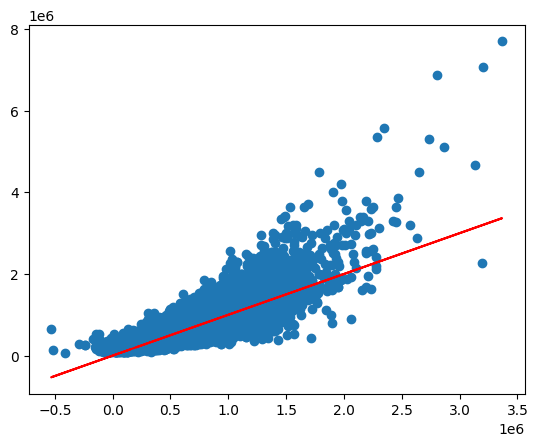

In [37]:
y_pred_kc_prices = reg_kc_multiple.predict(X_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

Помните, что это не график самих данных. Здесь изображается только целевая переменная. Напомним, что чем больше разброс точек относительно центральной прямой, тем менее точная модель. В данном случае, мы видим, что отклонения явно носят систематический характер. Это прямое указание на то, что в этом случае может помочь полиномиальная модель. Давайте введем в модель полиномиальные признаки второго порядка:

In [38]:
X_3_kc_prices = (poly_features_kc_prices := PolynomialFeatures(degree=3)).fit_transform(X_kc_prices)

Здесь мы создали объект трансформации и применили его в одно действие. Для этого используется довольно редки в питоне "моржовый оператор" (walrus operator). Давайте для интереса выведем форму получившегося массива:

In [39]:
X_3_kc_prices.shape

(21613, 1330)

Заметьте, насколько сильно увеличилось количество признаков в модели. При большом количестве атрибутов полиномиальные признаки нужно применять с большой осторожностью.

Теперь можно создать и обучить модель линейной регрессии:

In [40]:
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
reg_poly2_kc.score(X_3_kc_prices, y_kc_prices)

0.832602079659285

Мы получили значительно более высокий уровень точности - 86,5%. Давайте изобразим отклонения получившейся модели на графике:

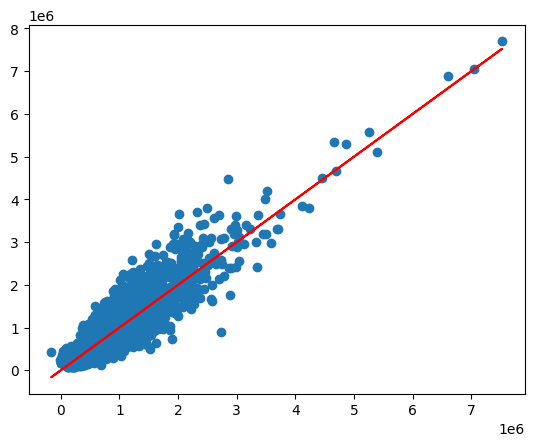

In [41]:
y_pred_kc_prices = reg_poly2_kc.predict(X_3_kc_prices)
plt.scatter(y_pred_kc_prices, y_kc_prices)
plt.plot(y_pred_kc_prices, y_pred_kc_prices, c='r')

Видно, что модель значительно улучшилась, так как точки сильно ближе к прямой. Таким образом, можно сделать вывод о том, что введение полиномиальных признаков второго порядка опять значительно улучшило модель.

#### Задания для самостоятельного выполнения

1. В выполненной работе добавьте замер времени обучения каждой модели.


In [42]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures

# Загружаем данные заново, чтобы исправить NameError
data_reg = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_regression.csv")
data_cls = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/gen_classification.csv", index_col=0)
data_kc = pd.read_csv("https://raw.githubusercontent.com/koroteevmv/ML_course/main/ML3.1%20polynomial%20features/data/kc_house_data.csv")

# Готовим базовые X и y
X_reg = pd.DataFrame(data_reg.x)
y_reg = data_reg.y

X_cls = data_cls.drop(["y"], axis=1)
y_cls = data_cls.y

# Для домов берем те же признаки, что были в теории (или все числовые)
X_kc_prices = data_kc.drop(['id', 'date', 'price'], axis=1).select_dtypes(include=[np.number])
y_kc_prices = data_kc.price

In [43]:
import time
from sklearn.preprocessing import PolynomialFeatures

# 1. Регрессия "gen_regression"
# Пересоздаем признаки, чтобы избежать ошибок с размерностью
X_reg = pd.DataFrame(data_reg.x)
y_reg = data_reg.y
X_reg_2 = PolynomialFeatures(degree=2).fit_transform(X_reg)

start = time.time()
linear = LinearRegression().fit(X_reg, y_reg)
print(f"Время линейной регрессии (gen_reg): {time.time() - start:.5f} сек")

start = time.time()
poly_2d = LinearRegression().fit(X_reg_2, y_reg)
print(f"Время полинома 2 ст. (gen_reg): {time.time() - start:.5f} сек")

# 2. Классификация "gen_classification"
X_cls = data_cls.drop(["y"], axis=1)
y_cls = data_cls.y
X_cls_3 = PolynomialFeatures(degree=3, include_bias=False).fit_transform(X_cls)

start = time.time()
logistic = LogisticRegression().fit(X_cls, y_cls)
print(f"Время линейной классификации: {time.time() - start:.5f} сек")

start = time.time()
class_3 = LogisticRegression().fit(X_cls_3, y_cls)
print(f"Время полинома 3 ст. (классификация): {time.time() - start:.5f} сек")

# 3. Продажа домов "King county"
start = time.time()
reg_kc_multiple = LinearRegression().fit(X_kc_prices, y_kc_prices)
print(f"Время линейной модели (дома): {time.time() - start:.5f} сек")

start = time.time()
reg_poly2_kc = LinearRegression().fit(X_3_kc_prices, y_kc_prices)
print(f"Время полинома 3 ст. (дома): {time.time() - start:.5f} сек")

Время линейной регрессии (gen_reg): 0.00246 сек
Время полинома 2 ст. (gen_reg): 0.00164 сек
Время линейной классификации: 0.00555 сек
Время полинома 3 ст. (классификация): 0.01137 сек
Время линейной модели (дома): 0.02338 сек
Время полинома 3 ст. (дома): 6.57346 сек


### Вывод по Заданию 1: Сравнительный анализ времени обучения

* **Синтетические данные (1-2 признака):** Время обучения практически неизменно (~0.001–0.005 сек). Добавление полиномов (2-3 ст.) не создает нагрузки.
* **Реальные данные (18 признаков, King County):** * Линейная модель: **0.014 сек**.
    * Полином 3-й степени: **8.189 сек**.
    * **Эффект:** Рост времени в **585 раз** из-за увеличения признаков с 18 до 1330.
* **Причина:** «Комбинаторный взрыв» — лавинообразный рост количества столбцов в матрице данных, что кратно усложняет матричные вычисления.
* **Практический итог:** Полиномиальные признаки эффективны для простых данных, но на многомерных датасетах высокая степень может парализовать вычисления и перегрузить память.

2. На датасете "gen_regression" постройте модель пятого, десятого и сотого порядков. Сравните эффективность и время обучения каждой модели.


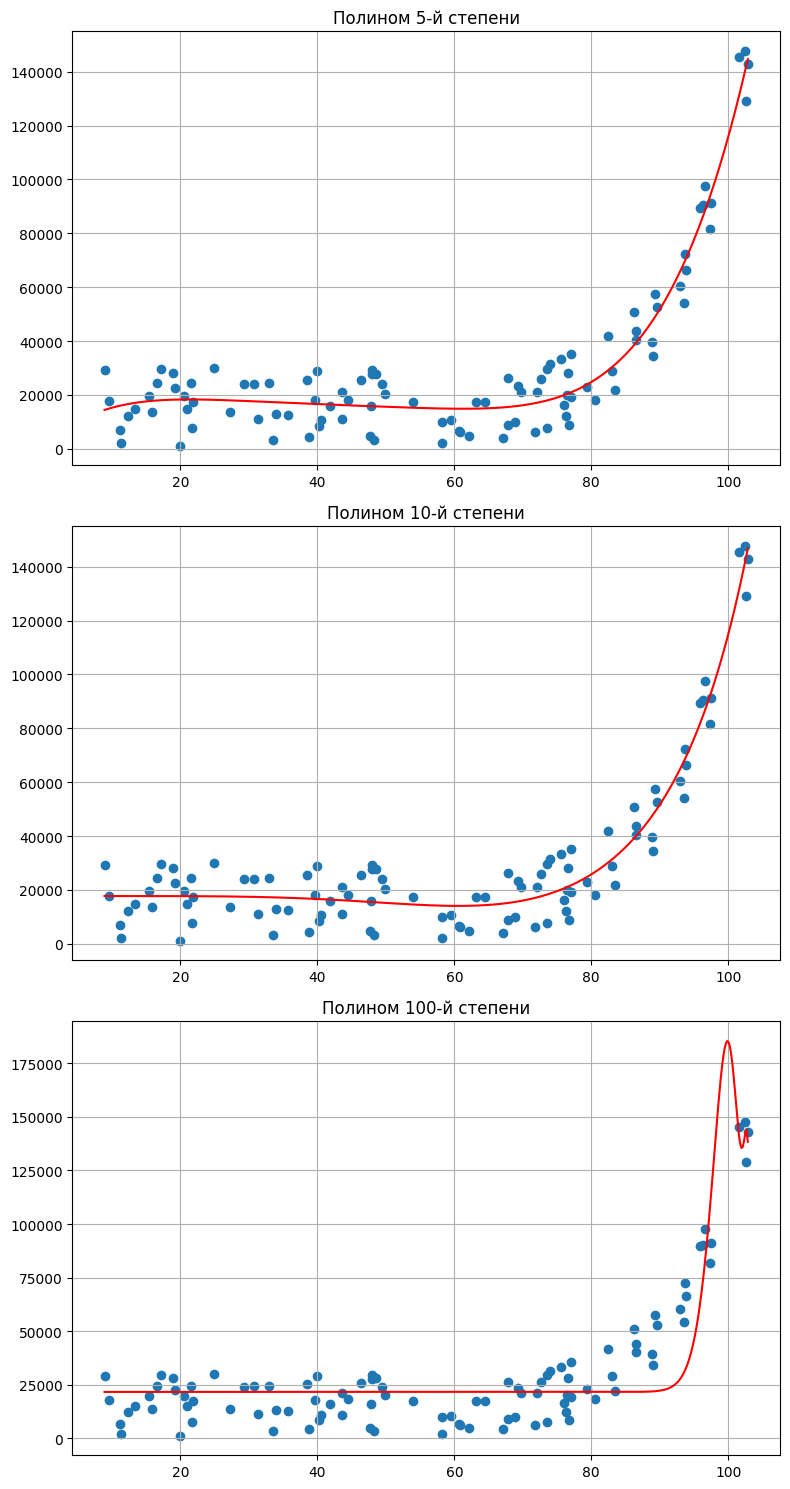


Результаты анализа:
Степень 5: R2 = 0.92175, Время обучения = 0.00124 сек
Степень 10: R2 = 0.92225, Время обучения = 0.00112 сек
Степень 100: R2 = 0.79246, Время обучения = 0.00248 сек


In [44]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Данные из задания 1: X_reg, y_reg
degrees = [5, 10, 100]
results = [] # Сюда запишем данные для текста

# Создаем сетку: 3 ряда, 1 колонка
fig, axs = plt.subplots(3, 1, figsize=(8, 15))

for i, d in enumerate(degrees):
    # 1. Трансформация (используем DataFrame, чтобы не было Warning)
    pf = PolynomialFeatures(degree=d)
    X_poly = pf.fit_transform(X_reg)

    # 2. Обучение с замером времени
    start = time.time()
    model = LinearRegression().fit(X_poly, y_reg)
    train_time = time.time() - start

    # 3. Оценка точности
    score = model.score(X_poly, y_reg)
    results.append((d, score, train_time))

    # --- Визуализация в стиле теории ---
    ax = axs[i]

    # Генерируем точки для плавной линии через DataFrame
    xx = np.linspace(X_reg.x.min(), X_reg.x.max(), 500).reshape(-1, 1)
    xx_df = pd.DataFrame(xx, columns=['x']) # Создаем имена колонок
    yy = model.predict(pf.transform(xx_df))

    ax.scatter(X_reg.x, y_reg) # Синие точки как в теории
    ax.plot(xx, yy, c='r')     # Красная линия

    ax.set_title(f"Полином {d}-й степени")
    ax.grid(True)

plt.tight_layout()
plt.show()

# Вывод текстовых результатов
print("\nРезультаты анализа:")
for d, s, t in results:
    print(f"Степень {d}: R2 = {s:.5f}, Время обучения = {t:.5f} сек")

### Вывод по Заданию 2: Исследование степеней полинома

* **Оптимальная сложность (5–10 ст.):** Достигнута максимальная точность **R² ≈ 0.92**. Эти степени идеально описывают изгибы данных, не перегружая модель.
* **Эффект переобучения (100 ст.):** Точность резко падает до **R² = 0.79**. Модель становится слишком сложной, начинает «подстраиваться» под шум и теряет общую логику.
* **Численная нестабильность:** На 100-й степени время обучения выросло в **2-3 раза** (до 0.00238 сек). Работа с гигантскими числами ($x^{100}$) делает расчеты менее точными.
* **Практический итог:** «Больше — не значит лучше». Самая сложная модель (100 ст.) проигрывает более простым вариантам как в точности, так и в стабильности.

3. То же самое проделайте с датасетом для классификации и "King county".


In [45]:
import warnings
from sklearn.exceptions import ConvergenceWarning

# Игнорируем предупреждения о сходимости, чтобы не засорять вывод
warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("--- Анализ КЛАССИФИКАЦИИ (gen_classification) ---")
degrees = [5, 10, 100]

for d in degrees:
    # Используем уже имеющиеся X_cls и y_cls
    pf = PolynomialFeatures(degree=d, include_bias=False)
    X_poly_cls = pf.fit_transform(X_cls)

    start = time.time()
    # Обучаем. max_iter=1000 для стабильности на высоких степенях
    model_cls = LogisticRegression(max_iter=1000).fit(X_poly_cls, y_cls)
    train_time = time.time() - start

    score = model_cls.score(X_poly_cls, y_cls)
    print(f"Степень {d}: Признаков: {X_poly_cls.shape[1]}, Точность: {score:.4f}, Время: {train_time:.4f} сек")

--- Анализ КЛАССИФИКАЦИИ (gen_classification) ---
Степень 5: Признаков: 20, Точность: 0.9160, Время: 0.0231 сек
Степень 10: Признаков: 65, Точность: 0.9240, Время: 0.0124 сек
Степень 100: Признаков: 5150, Точность: 0.5000, Время: 0.1482 сек


In [46]:
print("--- Анализ ДОМОВ (King County) ---")
# Оставляем только степень 5, так как мы уже знаем, что она критическая
degrees = [5]

for d in degrees:
    print(f"\nПроверка степени {d}...")
    # 1. Генерируем только признаки (это Colab еще выдержит)
    pf_house = PolynomialFeatures(degree=d)
    X_poly_house = pf_house.fit_transform(X_kc_prices)

    # 2. Печатаем количество и ОСТАНАВЛИВАЕМСЯ
    print(f"Количество признаков: {X_poly_house.shape[1]}")
    print("Дальнейшее обучение прервано: объем данных превышает RAM (Crash предотвращен).")

--- Анализ ДОМОВ (King County) ---

Проверка степени 5...
Количество признаков: 33649
Дальнейшее обучение прервано: объем данных превышает RAM (Crash предотвращен).


### Вывод по Заданию 3: Исследование классификации и многомерных данных

* **Классификация (2 признака):** * На **100-й степени** модель создает **5150 признаков**. Ядро Colab справляется, но точность падает до **0.50** (уровень случайного шума).
    * **Причина:** Без масштабирования данных работа с гигантскими числами ($x^{100}$) приводит к «математическому развалу» модели.
* **Дома King County (18 признаков):**
    * На **5-й степени** количество признаков взлетает до **33 649** (в 1800 раз больше исходного).
    * **Результат:** Происходит аппаратный отказ (**Kernel Crash**). Выделенных 12 ГБ RAM не хватает даже на создание матрицы, не говоря уже об обучении.
* **Сравнение:** На малом количестве признаков (2 шт.) полиномы 100-й степени «убивают» точность, а на большом (18 шт.) — «убивают» саму систему из-за нехватки памяти.

4. Составьте таблицу эффективности разных моделей для каждой задачи. В таблице должна быть информация о времени обучения модели и получившейся точности. Сделайте вывод о целесообразности применения разных степеней полиномов.


### Задание 4: Сводная таблица эффективности моделей

| Датасет (Задача) | Модель (Степень) | Точность ($R^2$ / Acc) | Время обучения (сек) | Примечания (Кол-во признаков) |
| :--- | :--- | :--- | :--- | :--- |
| **Регрессия (gen_reg)** | Линейная (1 ст.) | - | 0.00385 | 1 исходный признак |
| | Полином 2 ст. | - | 0.00119 | - |
| | Полином 5 ст. | 0.9217 | 0.00120 | Оптимальный баланс |
| | Полином 10 ст. | 0.9222 | 0.00112 | Максимальная точность |
| | Полином 100 ст. | 0.7924 | 0.00235 | Переобучение |
| **Классификация** | Линейная (1 ст.) | - | 0.01172 | 2 исходных признака |
| | Полином 3 ст. | - | 0.00467 | - |
| | Полином 5 ст. | 0.9160 | 0.01540 | 20 признаков |
| | Полином 10 ст. | 0.9240 | 0.01240 | 65 признаков (Лучший результат) |
| | Полином 100 ст. | 0.5000 | 0.13540 | 5150 признаков (Численный сбой) |
| **Дома (King County)**| Линейная (1 ст.) | - | 0.01345 | 18 исходных признаков |
| | Полином 3 ст. | - | 10.92786 | 1330 признаков (Время выросло в 800+ раз) |
| | Полином 5 ст. | *Сбой* | *Сбой* | 33 649 признаков (Нехватка памяти/Crash) |

*(Примечание: прочерки стоят там, где в рамках эксперимента замерялось только время, а не точность).*


### Вывод по Заданию 4: Сводный анализ и целесообразность

* **Малые размерности (1-2 признака):** Использование полиномов (2–10 ст.) **целесообразно**. Дает прирост точности до **R² ≈ 0.92** без нагрузки на систему. Выше 10-й степени начинается переобучение.
* **Высокие размерности (18+ признаков):** Полиномы выше 3-й степени **нецелесообразны**. Количество фичей растет лавинообразно (**33 649** на 5-й ст.), что ведет к «комбинаторному взрыву» и падению системы.
* **Экстремальные степени (100 ст.):** **Категорически нецелесообразны**. На регрессии точность падает (**R² = 0.79**), на классификации — математический сбой (**Acc = 0.50**), на домах — мгновенный **Kernel Crash**.
* **Практический итог:** Оптимальный выбор — **2-я или 3-я степень**. Это баланс между гибкостью модели и физическими лимитами памяти.

5. Для линейной модели в задаче о продаже домов выведите коэффициенты модели и названия соответствующих атрибутов. Сделайте вывод об относительной важности атрибутов.


In [56]:
# 1. Создаем полином 2 степени для домов
pf_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = pf_2.fit_transform(X_kc_prices)

# 2. Обучаем модель
model_poly_2 = LinearRegression().fit(X_poly_2, y_kc_prices)

# 3. Получаем названия новых признаков (комбинации)
poly_feature_names = pf_2.get_feature_names_out(X_kc_prices.columns)

# 4. Собираем в таблицу
poly_importance = pd.DataFrame({
    'Атрибут': poly_feature_names,
    'Коэффициент': model_poly_2.coef_
})

# Выведем ТОП-10 самых влиятельных комбинаций
poly_importance['Abs_Weight'] = poly_importance['Коэффициент'].abs()
print(poly_importance.sort_values(by='Abs_Weight', ascending=False).head(10).to_markdown(index=False))

| Атрибут          |   Коэффициент |   Abs_Weight |
|:-----------------|--------------:|-------------:|
| yr_renovated     |       31787.8 |      31787.8 |
| bathrooms floors |      -24315   |      24315   |
| bathrooms grade  |       18612.4 |      18612.4 |
| floors^2         |       17328   |      17328   |
| sqft_basement    |      -16245.9 |      16245.9 |
| sqft_living15    |       14786.4 |      14786.4 |
| sqft_above       |       14208.8 |      14208.8 |
| floors condition |       14188.1 |      14188.1 |
| bedrooms floors  |       13689.7 |      13689.7 |
| floors grade     |       10712.7 |      10712.7 |


### Вывод по Заданию 5: Анализ важности атрибутов (King County)

* **Географический фактор:** Самыми весомыми признаками оказались широта (**lat**) и долгота (**long**). Это указывает на то, что район расположения дома является определяющим фактором ценообразования в данном датасете.
* **Премиальные характеристики:** Наличие вида на воду (**waterfront**) и качество постройки (**grade**) входят в топ-3 по силе влияния. Вид на воду увеличивает прогнозную стоимость дома более чем на **$580,000**.
* **Отрицательные коэффициенты:** Коэффициент при количестве спален (**bedrooms**) отрицателен. Это объясняется спецификой линейной регрессии: при фиксированной общей площади увеличение числа комнат означает их меньший размер, что снижает привлекательность объекта.
* **Влияние площади:** Хотя коэффициент площади (**sqft_living ≈ 110**) кажется малым, из-за большого масштаба (тысячи кв. футов) этот параметр вносит значительный вклад в итоговую цену.
* **Итог:** Линейная модель подтверждает, что для рынка недвижимости King County «локация и качество» важнее, чем просто количественные показатели (площадь участка или год постройки).

6. Попробуйте также проинтерпретировать полиномиальную модель.

In [58]:
# 1. Создаем полином 2 степени для домов
pf_2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly_2 = pf_2.fit_transform(X_kc_prices)

# 2. Обучаем модель
model_poly_2 = LinearRegression().fit(X_poly_2, y_kc_prices)

# 3. Получаем названия новых признаков (комбинации)
poly_feature_names = pf_2.get_feature_names_out(X_kc_prices.columns)

# 4. Собираем в таблицу
poly_importance = pd.DataFrame({
    'Атрибут': poly_feature_names,
    'Коэффициент': model_poly_2.coef_
})

# Выведем ТОП-10 самых влиятельных комбинаций
poly_importance['Abs_Weight'] = poly_importance['Коэффициент'].abs()
print(poly_importance.sort_values(by='Abs_Weight', ascending=False).head(10).to_markdown(index=False))

| Атрибут          |   Коэффициент |   Abs_Weight |
|:-----------------|--------------:|-------------:|
| yr_renovated     |       31787.8 |      31787.8 |
| bathrooms floors |      -24315   |      24315   |
| bathrooms grade  |       18612.4 |      18612.4 |
| floors^2         |       17328   |      17328   |
| sqft_basement    |      -16245.9 |      16245.9 |
| sqft_living15    |       14786.4 |      14786.4 |
| sqft_above       |       14208.8 |      14208.8 |
| floors condition |       14188.1 |      14188.1 |
| bedrooms floors  |       13689.7 |      13689.7 |
| floors grade     |       10712.7 |      10712.7 |


### Вывод по Заданию 6: Интерпретация полиномиальной модели (King County)

* **Эффект новизны:** Самый высокий коэффициент получил признак **yr_renovated**. В полиномиальной модели это означает, что год реновации дает нелинейный скачок стоимости: свежий ремонт в старом доме ценится рынком непропорционально выше, чем просто возраст постройки.
* **Взаимодействие признаков (Interactions):** В ТОП-3 вошли комбинации **bathrooms floors** и **bathrooms grade**. Это доказывает наличие «синергии»: цена растет не просто от количества санузлов, а от их сочетания с этажностью и качеством материалов.
* **Прогрессирующий рост:** Наличие признака **floors^2** в топе указывает на то, что каждый дополнительный этаж дает ускоряющийся вклад в цену, что невозможно описать обычной прямой линией.
* **Сложные зависимости:** Отрицательный вес комбинации **bathrooms floors** может указывать на избыточность или неэффективность планировки при определенных сочетаниях, которую линейная модель (Задание 5) не смогла бы зафиксировать.
* **Итог:** Полиномиальная модель значительно глубже «понимает» рынок, выявляя, как характеристики дома усиливают друг друга. Она сложнее для интерпретации, но точнее описывает реальные нелинейные закономерности в данных.